In [1]:
# Load libraries and set up environment
import os 
import sys
import importlib
import datetime
import numpy as np
import pandas as pd
import anndata as ad    
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import gffutils
import anndata as ad
import scanpy as sc 
from tqdm import tqdm

# Ensure CUDA is available and if not use CPU
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("CUDA device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA device found")

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

float_type = {"device": device, "dtype": torch.float}
if device.type == "cuda":
    torch.set_default_tensor_type(torch.cuda.FloatTensor)

# Set seed for reproducibility
torch.manual_seed(0)

# Configure plotting styles
sns.set_theme()
sc.set_figure_params(figsize=(7, 7), frameon=True, dpi=80, facecolor='white')

# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.LeafletFA as LeafletFA
import BetaDirichletFactor.LeafletFAminibatch as LeafletFAminibatch
import BetaDirichletFactor.differential_splicing as ds
import BetaDirichletFactor.utils as utils
import visualization.IsovizPy as ja
import evaluations.cost_correlation_assign as cca

# Reload custom modules
importlib.reload(LeafletFA)
importlib.reload(ds)
importlib.reload(utils)

# Simulation source code
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/")
import simulate_counts as sim 
importlib.reload(sim)


Torch version: 2.4.1.post300
CUDA available: True
CUDA device count: 3
CUDA device name: NVIDIA L40S
Using device: cuda


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/torch/__init__.py:955: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1728241823685/work/torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


Torch Version: 2.4.1.post300
CUDA Version: 12.0
Torch Version: 2.4.1.post300
CUDA Version: 12.0
Torch Version: 2.4.1.post300
CUDA Version: 12.0


<module 'simulate_counts' from '/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/simulate_counts.py'>

In [2]:
# Define base output directory
import json 
base_output_dir = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis/2025-02-19"

# Get parameter set ID from command line
# param_id = int(sys.argv[1])
param_id = 0 

# Load parameters
param_file = os.path.join(base_output_dir, "parameter_combinations.json")
with open(param_file, "r") as f:
    param_list = json.load(f)
params = param_list[param_id] 

# Define output directory
output_dir = os.path.join(base_output_dir, f"run_{param_id}")
os.makedirs(output_dir, exist_ok=True)
print(f"All outputs will be saved in {output_dir}")

All outputs will be saved in /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis/2025-02-19/run_0


In [3]:
# Anndata file input file path 
ATSE_anndata_file="/gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/DATA_FILES/BRAIN_ONLY/02112025/TMS_Anndata_ATSE_counts_with_waypoints_20250211_171237.h5ad"
ATSE_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/ATSEmap/output/ATSEfiles/TMS_atse_file_unanno_also_2025-01-30_19-24-18.txt.gz"

In [4]:
# Load splicing anndata file along with the ATSE annotation file (both obtained using upstream processing within LeafletFA framework)
adata = ad.read_h5ad(ATSE_anndata_file)
atses = pd.read_csv(ATSE_file, sep="\t")

### Simulate data!

In [5]:
# Filter adata to only include junctions that have non_zero_count_cells >= 10
adata = adata[:, adata.var["non_zero_count_cells"] > 2]

# choose which column should be used for maintaining cell labels when simulating data...
sim_label_column = params["sim_label_column"] #"cell_type_grouped" # or set to None then cells will be randomly assigned to groups
proportion_negative = params["proportion_negative"]

if params["sim_label_column"] is None:
    K = 2
else:
    K = len(adata.obs[sim_label_column].unique())

# Set up some useful params 
params["input_conc"] = None if params["input_conc"] is None else torch.tensor(np.inf)
input_conc = params["input_conc"]
junc_specific_prior = params["junc_specific_prior"] # set to True if you want to use a junc-specific prior (a set of a,b shape params for each junction) or False to learn one set of a,b shape params for all junctions
waypoints_use = params["waypoints_use"] # don't have waypoints in simulated data

In [6]:
sim_label_column = "cell_type_grouped"
K = len(adata.obs[sim_label_column].unique())
proportion_negative = 0.5
print(K)

9


In [7]:
# Preprocess the data
adata_filtered = sim.preprocess_adata(adata, sim_label_column, "cell_by_cluster_matrix")
# Simulate data
_, _, adata_input, cell_type_psi_df = sim.simulate_and_prepare_data(adata_filtered, K, float_type, proportion_negative, sim_label_column)

# Write cell_type_psi_df to a CSV file 
cell_type_psi_df_path = os.path.join(output_dir, 'cell_type_psi_df.csv')
cell_type_psi_df.to_csv(cell_type_psi_df_path, index=False)

Filtering ATSEs to remove those very unevenly distributed across cell types!


100%|██████████| 9/9 [00:27<00:00,  3.10s/it]
/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/simulate_counts.py:281: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_junc_counts =  adata_input.var.groupby(["event_id"]).agg({"junction_id": "count"}).reset_index()


Cluster_Counts nnz: 14507235
Junction_Counts nnz: 8005369
The number of unique junctions included in the simulation data is: 10170
The number of unique clusters included in the simulation data is: 3390


/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/simulate_counts.py:307: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cluster, juncs_c in tqdm( adata_input.var.groupby("event_id")):
100%|██████████| 3390/3390 [00:02<00:00, 1200.82it/s]
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Cluster_Counts nnz: 14004504
Junction_Counts nnz: 7578659
The proportion of negative ASEs to set is: 0.5
The number of cell types is: 9
The number of cells is: 19942
The number of junctions is: 9798
Number of negative labels (0): 1633
Number of positive labels (1): 1633


...

Processing ATSEs: 100%|██████████| 3266/3266 [01:02<00:00, 52.53it/s]
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


Done normalizing junction counts by cluster!
Done simulating junction counts!
True label counts:
 true_label
negative    4899
positive    4899
Name: count, dtype: int64
Sample label counts:
 sample_label
negative    4899
positive    4899
Name: count, dtype: int64


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: Layer 'junc_ratio' should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


Cluster_Counts nnz: 13834584
Junction_Counts nnz: 11977270
Data successfully simulated and prepared!


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)
/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/simulate_counts.py:405: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1728241823685/work/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ).to_sparse_csr()


In [8]:
# Check column names that are not strings
problematic_columns = [col for col in adata_input.var.columns if not isinstance(col, str)]
print("Problematic columns:", problematic_columns)

# Convert problematic column names to strings
adata_input.var.columns = adata_input.var.columns.map(str)

if adata_input.var.columns.duplicated().any():
    print("Duplicate column names found. Resolving by renaming.")
    adata_input.var.columns = pd.io.parsers.ParserBase({'names': adata_input.var.columns})._maybe_dedup_names(adata_input.var.columns)

import scipy 
from scipy.sparse import csr_matrix

# Check if any layers are in COO format
for layer_name, layer_data in adata_input.layers.items():
    if isinstance(layer_data, scipy.sparse.coo_matrix):
        print(f"Converting {layer_name} from COO to CSR format.")
        adata_input.layers[layer_name] = layer_data.tocsr()

# Convert adata.X if it is in COO format
if isinstance(adata_input.X, scipy.sparse.coo_matrix):
    print("Converting adata.X from COO to CSR format.")
    adata_input.X = adata_input.X.tocsr()

# Convert varm, obsm, and obsp if they contain COO matrices
for attr in ['varm', 'obsm', 'obsp']:
    for key in getattr(adata_input, attr).keys():
        if isinstance(getattr(adata_input, attr)[key], scipy.sparse.coo_matrix):
            print(f"Converting {attr}['{key}'] from COO to CSR format.")
            getattr(adata_input, attr)[key] = getattr(adata_input, attr)[key].tocsr()


Problematic columns: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Converting cell_by_junction_matrix from COO to CSR format.
Converting cell_by_cluster_matrix from COO to CSR format.


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


In [9]:
# save adata_input to h5ad file
# output_anndata = "/gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/DATA_FILES/SIMULATED"
# get todays date
# today = datetime.datetime.now()
# today = today.strftime("%Y-%m-%d")
# adata_input.write_h5ad(f"{output_anndata}/simulated_data_{today}.h5ad")
# print(f"Simulated anndata saved to {output_anndata}/simulated_data_{today}.h5ad")

### Initialize and train the model using the simulated counts!

In [36]:
num_inits = params["num_inits"]
num_epochs = 10
num_samples = params["num_samples"]
lr = params["lr"]
ELBO_num_particles = params["ELBO_num_particles"]

In [63]:
lr = 0.9
num_inits = 1

In [65]:
adata_input

AnnData object with n_obs × n_vars = 19942 × 9798
    obs: 'cell_id', 'age', 'batch', 'cell_ontology_class', 'method', 'mouse.id', 'sex', 'tissue', 'old_cell_id_index', 'cell_clean', 'cell_id_index', 'subtissue_clean', 'cell_type_grouped', 'cell_type'
    var: 'junction_id', 'event_id', 'splice_motif', 'label_5_prime', 'label_3_prime', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'non_zero_count_cells', 'non_zero_cell_prop', 'annotation_status_score', 'non_zero_cell_prop_score', 'splice_motif_score', 'junction_id_index', 'chr', 'start', 'end', 'index', '0', '1', '2', '3', '4', '5', '6', '7', '8', 'sample_label', 'difference', 'true_label'
    uns: 'age_colors', 'neighbors', 'pca_explained_variance_ratio', 'tissue_colors', 'umap', 'cell_type_colors'
    obsm: 'X_pca', 'X_umap', 'phi_init_100_waypoints', 'phi_init_30_waypoints', 'X_PHI'
    varm: 'psi_init_100_waypoints', 'psi_init_30_waypoints'
    layers: 'c

In [87]:
# Let's initialize the LeafletFA class 
importlib.reload(LeafletFAminibatch)

Torch Version: 2.4.1.post300
CUDA Version: 12.0


<module 'BetaDirichletFactor.LeafletFAminibatch' from '/gpfs/commons/home/kisaev/Leaflet-private/src/BetaDirichletFactor/LeafletFAminibatch.py'>

In [90]:
leaflet_model = LeafletFAminibatch.LeafletFA(adata=adata_input, K=K, 
                                    junc_specific_prior = junc_specific_prior, 
                                    waypoints_use=waypoints_use, 
                                    batch_size=1534,
                           input_conc_prior = input_conc, 
                           num_epochs=50, 
                           print_epochs=1, 
                           ELBO_num_particles=1, 
                           lr=0.9, gamma=0.5, 
                           num_samples=100)

# Convert AnnData into PyTorch tensors for model training 
leaflet_model.from_anndata()

Taking in the AnnData object with 19942 cells and 9798 junctions.
Processing AnnData on cuda


In [91]:
!export CUDA_LAUNCH_BLOCKING=1


In [92]:
leaflet_model

In [93]:
# Train the model 
leaflet_model.fit(guide=None)

Training in progress for 50 epochs!


13it [00:18,  1.43s/it]


Sum Loss: 585996463.35, Avg Loss: 29385.0398
Epoch 0: Total Loss: 585996463.35


13it [00:19,  1.54s/it]


Sum Loss: 554945612.09, Avg Loss: 27827.9818
Epoch 1: Total Loss: 554945612.09


...

13it [00:19,  1.49s/it]


Sum Loss: 526124571.58, Avg Loss: 26382.7385
Epoch 18: Total Loss: 526124571.58


13it [00:18,  1.41s/it]

Sum Loss: 526136423.19, Avg Loss: 26383.3328
Epoch 19: Total Loss: 526136423.19


[-585996463.3509469,
 -554945612.08584,
 -540979423.9118733,
 -536328271.6271678,
 -532840214.3260573,
 -530312599.64964706,
 -528801399.21106637,
 -527989079.3625355,
 -527371703.93411076,
 -527150398.747054,
 -526919367.67095447,
 -526834069.5589536,
 -526611890.6733673,
 -526540172.70253986,
 -526464832.82746583,
 -526376140.215336,
 -526364427.185242,
 -526271462.5896933,
 -526124571.5819062]

In [94]:
adata_input.shape

(19942, 9798)

Processing batch 1/13 for assignments
Processing batch 2/13 for assignments
Processing batch 3/13 for assignments
Processing batch 4/13 for assignments
Processing batch 5/13 for assignments
Processing batch 6/13 for assignments
Processing batch 7/13 for assignments
Processing batch 8/13 for assignments
Processing batch 9/13 for assignments
Processing batch 10/13 for assignments
Processing batch 11/13 for assignments
Processing batch 12/13 for assignments
Processing batch 13/13 for assignments


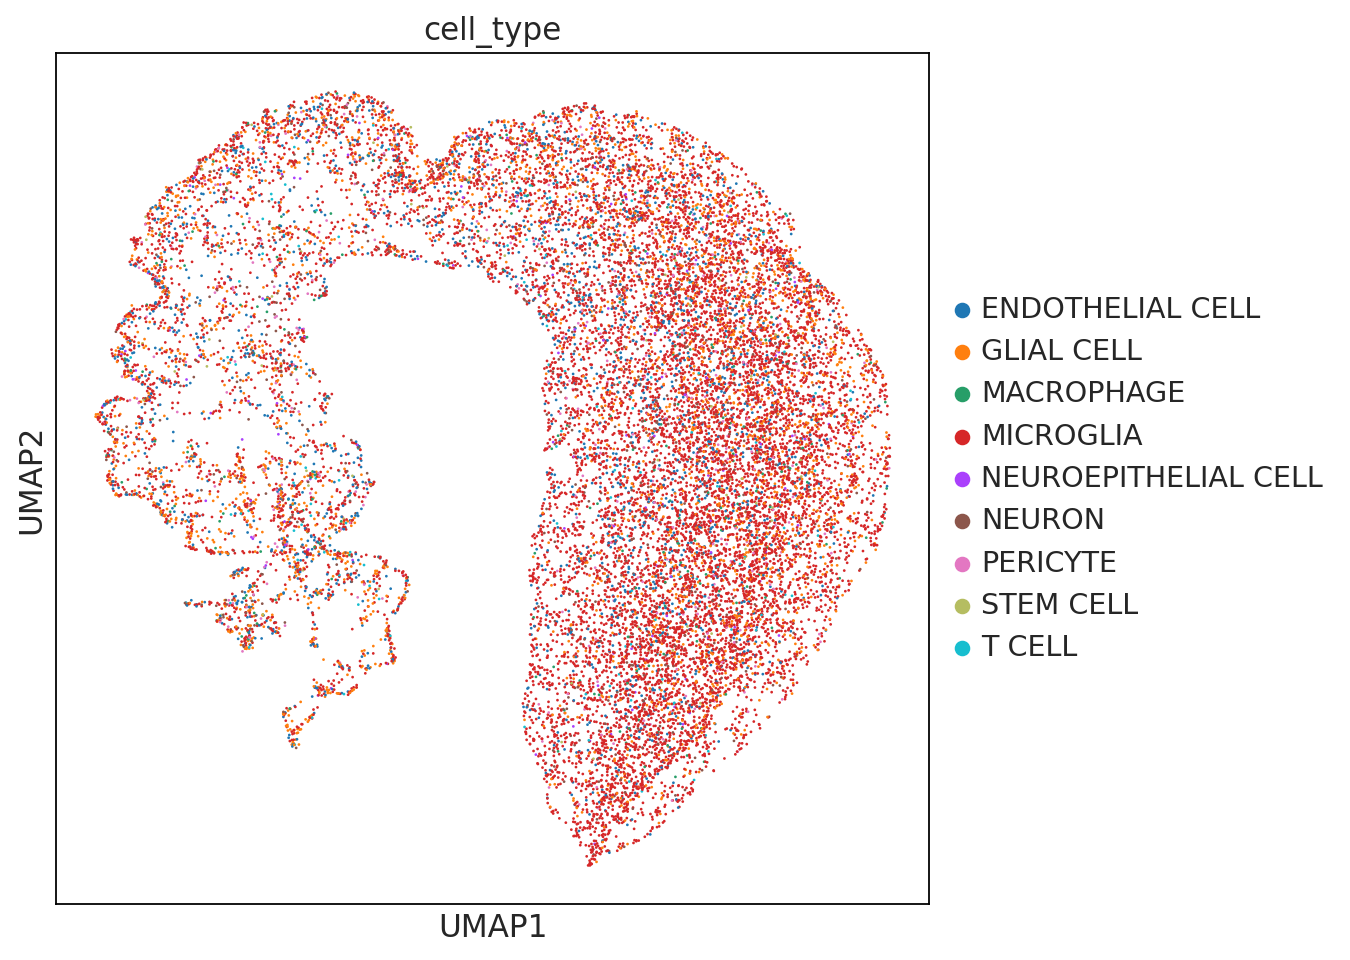

In [95]:
X_PHI = leaflet_model.get_cell_assignments()

# Add to adata_input 
adata_input.obsm["X_PHI"] = X_PHI

# Run UMAP on X_PHI 
sc.pp.neighbors(adata_input, use_rep="X_PHI", n_neighbors=15)
sc.tl.umap(adata_input, min_dist=0.5)

# Plot UMAP
sc.pl.umap(adata_input, color="cell_type")